In [1]:
# ==============================================================
# 0. 导入 & 全局配置
# ==============================================================
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.lines import Line2D
import copy
import pickle
import warnings

from numpy.linalg import svd
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_squared_error

from netdyn import *   # LVDynamics / SISDynamics / KuramotoDynamics 等

# 中文字体
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False
warnings.filterwarnings('ignore', category=UserWarning, module='matplotlib')

SEED = 42
np.random.seed(SEED)

In [2]:
# ==============================================================
# 1. 网络初始化 & 动力学模拟
# ==============================================================

def initialize_adjacency_matrix(matrix, seed=None):
    """将邻接矩阵中的 1 随机初始化为 [0.5, 1.5] 的权重，0 保持不变。"""
    if seed is not None:
        np.random.seed(seed)
    matrix = np.array(matrix, dtype=float)
    mask = (matrix == 1)
    matrix[mask] = np.random.uniform(0.5, 1.5, size=mask.sum())
    return matrix

In [4]:
# ==============================================================
# 3. 误差度量（NRMSE）
# ==============================================================

def compute_nrmse(X_true, X_pred):
    """
    归一化均方根误差（NRMSE）。

    NRMSE = ‖X_pred - X_true‖_F / ‖X_true‖_F

    范围 [0, ∞)，值越小表示越接近。
    经验阈值：< 0.05 强等价，0.05~0.15 弱等价，> 0.15 不等价。

    参数
    ----
    X_true, X_pred : np.ndarray，形状相同（T, N）或可广播

    返回
    ----
    nrmse : float
    """
    n      = min(len(X_true), len(X_pred))
    diff   = X_true[:n] - X_pred[:n]
    denom  = np.linalg.norm(X_true[:n], 'fro')
    if denom < 1e-12:
        return 0.0
    return float(np.linalg.norm(diff, 'fro') / denom)

In [5]:
def evaluate_prediction_nrmse(X_true, X_pred, t_split):
    """
    计算 t > t_split 区间的预测 NRMSE 及逐时刻 NRMSE。

    返回
    ----
    nrmse_t   : np.ndarray  逐时刻 NRMSE（各节点平均）
    nrmse_bar : float       全局 NRMSE
    """
    X_ref  = X_true[t_split:]
    X_pred = X_pred[t_split:]
    if len(X_ref) == 0:
        return None, None
    n          = min(len(X_ref), len(X_pred))
    diff       = X_ref[:n] - X_pred[:n]
    denom_t    = np.linalg.norm(X_ref[:n], axis=1, keepdims=True)
    denom_t    = np.where(denom_t < 1e-12, 1.0, denom_t)
    nrmse_t    = np.linalg.norm(diff, axis=1) / denom_t.squeeze()
    nrmse_bar  = compute_nrmse(X_ref[:n], X_pred[:n])
    return nrmse_t, nrmse_bar

In [7]:
# ==============================================================
# 5. 等价族构造
# ==============================================================

def construct_equivalent_network(A_eff_ref, U_dyn, sparsity_target,
                                  rho_ref=None, seed=None):
    """
    从给定的 A_eff_ref 出发，构造一个目标稀疏度的功能等价网络。

    原理：A' = A_eff_ref + N_null
    其中 N_null = Q @ R @ Q，Q = I - P 是 U_dyn 的零空间投影算符。
    N_null 满足 P @ N_null @ P ≈ 0，因此不改变 A_eff。

    参数
    ----
    A_eff_ref      : np.ndarray (N, N)  目标 A_eff（功能基准）
    U_dyn          : np.ndarray (N, k)  动力学子空间基底
    sparsity_target: float              目标保留边比例（如 0.05 = 5%）
    rho_ref        : float or None      谱半径归一化目标；None 则用 A_eff_ref 的谱半径
    seed           : int or None

    返回
    ----
    A_equiv : np.ndarray (N, N)  等价网络（非负权重，谱半径已归一化）
    delta   : float              实际 A_eff 偏差（验证用）
    """
    if seed is not None:
        np.random.seed(seed)
    N  = A_eff_ref.shape[0]
    P  = U_dyn @ U_dyn.T
    Q  = np.eye(N) - P

    # 零空间随机扰动
    R      = np.random.randn(N, N)
    N_null = Q @ R @ Q

    # 合成候选网络（取绝对值保证非负，与大多数生态/流行病模型一致）
    A_cand = np.abs(A_eff_ref + N_null)
    np.fill_diagonal(A_cand, 0.0)

    # 按目标稀疏度截断
    n_total  = N * N - N          # 不含对角线
    n_keep   = max(1, int(sparsity_target * n_total))
    flat     = A_cand.copy()
    np.fill_diagonal(flat, 0.0)
    threshold = np.sort(flat.flatten())[-n_keep]
    A_out     = np.where(flat >= threshold, flat, 0.0)
    np.fill_diagonal(A_out, 0.0)

    # 谱半径归一化
    if rho_ref is None:
        rho_ref = float(np.max(np.abs(np.linalg.eigvals(A_eff_ref))))
    rho_out = float(np.max(np.abs(np.linalg.eigvals(A_out))))
    if rho_out > 1e-9:
        A_out *= rho_ref / rho_out

    # 计算实际 A_eff 偏差（验证）
    delta = _aeff_deviation(A_out, A_eff_ref, U_dyn)

    return A_out, delta

In [8]:
def build_equivalence_family(A_eff_ref, U_dyn, sparsity_levels,
                              n_samples_per_level=5, rho_ref=None, seed=0):
    """
    构造不同稀疏度下的等价族——每个稀疏度生成多个形态各异的等价网络。

    参数
    ----
    A_eff_ref          : np.ndarray (N, N)
    U_dyn              : np.ndarray (N, k)
    sparsity_levels    : list of float  目标稀疏度列表
    n_samples_per_level: int            每个稀疏度生成的网络数量
    rho_ref            : float or None
    seed               : int            随机基础种子

    返回
    ----
    family : list of dict，每项含：
             sparsity / seed / A_equiv / delta
    """
    family = []
    for sp in sparsity_levels:
        for s in range(n_samples_per_level):
            A_eq, delta = construct_equivalent_network(
                A_eff_ref, U_dyn,
                sparsity_target=sp,
                rho_ref=rho_ref,
                seed=seed + s * 100 + int(sp * 1000)
            )
            family.append({
                "sparsity": sp,
                "seed":     seed + s * 100 + int(sp * 1000),
                "A_equiv":  A_eq,
                "delta":    delta,
            })
    print(f"等价族构造完成：{len(sparsity_levels)} 个稀疏度 × "
          f"{n_samples_per_level} 个样本 = {len(family)} 个网络")
    return family

In [9]:
# ==============================================================
# 6. 简并性验证实验
# ==============================================================

def verify_equivalence_family(family, model, X_obs, T_train_steps,
                               T_sim=500, seed=42):
    """
    对等价族中的每个网络运行动力学模拟，计算 NRMSE 验证功能等价性。

    参数
    ----
    family        : list of dict，由 build_equivalence_family 返回
    model         : NetworkDynamics
    X_obs         : np.ndarray (T, N)  完整 Ground Truth 轨迹
    T_train_steps : int
    T_sim         : int  模拟步数
    seed          : int

    返回
    ----
    results : list of dict，每项在 family 原有字段基础上增加：
              nrmse / X_pred
    """
    np.random.seed(seed)
    init_state = X_obs[T_train_steps]
    steps_pred = len(X_obs) - T_train_steps
    X_train    = X_obs[:T_train_steps]

    results = []
    print(f"\n{'稀疏度':>8} {'seed':>8} {'δ(A_eff)':>10} {'NRMSE':>8} {'等价性':>8}")
    print("─" * 50)

    for item in family:
        try:
            X_pred = model.simulate(
                item["A_equiv"], T_steps=steps_pred, init_state=init_state
            )
            X_full = np.vstack([X_train, X_pred])
            _, nrmse = evaluate_prediction_nrmse(X_obs, X_full, T_train_steps)
        except Exception as e:
            print(f"  模拟失败（seed={item['seed']}）：{e}")
            nrmse  = np.inf
            X_full = None

        label = ("强等价" if nrmse < 0.05 else
                 "弱等价" if nrmse < 0.15 else "不等价")

        results.append({**item, "nrmse": nrmse, "X_pred": X_full})
        print(f"{item['sparsity']:>8.3f} {item['seed']:>8} "
              f"{item['delta']:>10.4f} {nrmse:>8.4f} {label:>8}")

    return results

In [26]:
# ==============================================================
# 7. 可视化
# ==============================================================

def _save_or_show(fig, save_path):
    if save_path is not None:
        fig.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"图片已保存：{save_path}")
        plt.close(fig)
    else:
        plt.show()


def plot_trajectory_comparison(A_true, A_proxy, X_obs, X_proxy,
                                T_train_steps, num_nodes=10,
                                scatter_interval=3,
                                name_proxy="A_proxy",
                                save_path=None):
    """
    对比两个网络的拓扑热图及动力学轨迹（实线 vs 散点）。
    """
    N       = A_true.shape[0]
    T_total = X_obs.shape[0]
    t_ax    = np.arange(T_total)
    n_plot  = min(num_nodes, N)
    nodes   = np.linspace(0, N - 1, n_plot, dtype=int)
    colors  = [plt.cm.tab10(i % 10) for i in range(n_plot)]

    fig  = plt.figure(figsize=(14, 10))
    grid = plt.GridSpec(2, 2, height_ratios=[1, 1.5])

    for col, (A, cmap, name) in enumerate([
        (A_true,  'Blues', r'$A_{\rm true}$'),
        (A_proxy, 'Reds',  name_proxy)
    ]):
        ax  = fig.add_subplot(grid[0, col])
        cax = ax.imshow(A, cmap=cmap, interpolation='nearest')
        ax.set_title(name); fig.colorbar(cax, ax=ax)

    corr = np.corrcoef(A_true.flatten(), A_proxy.flatten())[0, 1]
    fig.axes[1].set_xlabel(f"拓扑相关系数：{corr:.4f}")

    ax3 = fig.add_subplot(grid[1, :])
    sp  = np.arange(0, T_total, scatter_interval)
    sp  = sp[sp < len(X_proxy)]
    for idx, node in enumerate(nodes):
        c = colors[idx]
        ax3.plot(t_ax, X_obs[:, node], color=c, lw=2, alpha=0.6)
        ax3.scatter(t_ax[sp], X_proxy[sp, node],
                    edgecolors=c, facecolors='none',
                    marker='o', s=40, lw=1.5)
    ax3.axvline(T_train_steps, color='k', ls=':', lw=2)
    ax3.legend([
        Line2D([0], [0], color='gray', lw=2),
        Line2D([0], [0], color='gray', marker='o', ls='None',
               markerfacecolor='none', markeredgewidth=1.5)
    ], ['Ground Truth', name_proxy], loc='upper left', fontsize=10)
    ax3.set_title(f"动力学对比（展示 {n_plot} 个节点）")
    ax3.set_xlabel("时间步"); ax3.set_ylabel(r"$x_i(t)$")
    ax3.grid(True, alpha=0.3)
    plt.tight_layout()
    _save_or_show(fig, save_path)


def plot_nrmse_comparison(X_obs, pred_dict, t_split, dt=0.1,
                           title=None, save_path=None):
    """
    对比多个网络在预测区间的逐时刻 NRMSE 曲线。

    参数
    ----
    pred_dict : dict {label: X_pred}
    """
    X_ref     = X_obs[t_split:]
    T_future  = len(X_ref)
    t_horizon = np.arange(T_future) * dt
    colors    = [plt.cm.tab10(i % 10) for i in range(len(pred_dict))]

    fig, ax = plt.subplots(figsize=(10, 6))
    print(f"{'标签':<35} {'全局 NRMSE':>12}")
    print("─" * 50)

    for (label, X_pred), color in zip(pred_dict.items(), colors):
        Xp   = X_pred[t_split:]
        n    = min(len(Xp), T_future)
        diff = X_ref[:n] - Xp[:n]
        denom_t = np.linalg.norm(X_ref[:n], axis=1)
        denom_t = np.where(denom_t < 1e-12, 1.0, denom_t)
        nrmse_t = np.linalg.norm(diff, axis=1) / denom_t
        nrmse_bar = compute_nrmse(X_ref[:n], Xp[:n])

        print(f"{label:<35} {nrmse_bar:>12.6f}")
        ax.plot(t_horizon[:n], nrmse_t, lw=1.8, color=color, label=label)

    ax.set_xlabel(r"预测时间 $\tilde{t}$", fontsize=12)
    ax.set_ylabel("NRMSE", fontsize=12)
    ax.set_title(title or "预测误差对比（NRMSE）", fontsize=13)
    ax.axhline(0.05, color='gray', ls='--', lw=1, alpha=0.6, label='强等价阈值 0.05')
    ax.axhline(0.15, color='gray', ls=':',  lw=1, alpha=0.6, label='弱等价阈值 0.15')
    ax.legend(fontsize=9, bbox_to_anchor=(1.02, 1), loc='upper left')
    ax.grid(True, linestyle=':', alpha=0.6)
    plt.tight_layout()
    _save_or_show(fig, save_path)


def plot_equivalence_family(results, nrmse_threshold=0.15, save_path=None):
    sparsities = sorted(set(r['sparsity'] for r in results))
    colors     = plt.cm.viridis(np.linspace(0, 0.9, len(sparsities)))
    sp_color   = {sp: c for sp, c in zip(sparsities, colors)}

    groups = {sp: [] for sp in sparsities}
    for r in results:
        if np.isfinite(r['nrmse']):
            groups[r['sparsity']].append(r['nrmse'])

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    ax   = axes[0]
    data = [groups[sp] for sp in sparsities]
    lbls = [f"{sp:.2f}" for sp in sparsities]
    bp   = ax.boxplot(data, labels=lbls, patch_artist=True)
    for patch, sp in zip(bp['boxes'], sparsities):
        patch.set_facecolor(sp_color[sp]); patch.set_alpha(0.7)
    ax.axhline(0.05, color='steelblue', ls='--', lw=1.2, label='Strong equiv. 0.05')
    ax.axhline(nrmse_threshold, color='tomato', ls='--', lw=1.2,
               label=f'Equiv. boundary {nrmse_threshold}')
    ax.set_xlabel("Target sparsity"); ax.set_ylabel("NRMSE")
    ax.set_title("Equivalence Family: NRMSE by Sparsity")
    ax.legend(fontsize=9); ax.grid(axis='y', alpha=0.3)

    ax = axes[1]
    for r in results:
        if not np.isfinite(r['nrmse']):
            continue
        ax.scatter(r['delta'], r['nrmse'],
                   color=sp_color[r['sparsity']], s=60, alpha=0.8,
                   edgecolors='k', lw=0.5)
    ax.axhline(nrmse_threshold, color='tomato', ls='--', lw=1.2,
               label=f'Equiv. boundary {nrmse_threshold}')
    ax.set_xlabel(r"$A_\mathrm{eff}$ deviation $\delta$")
    ax.set_ylabel("NRMSE")
    ax.set_title(r"$A_\mathrm{eff}$ Deviation vs Dynamical Error")
    ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

    from matplotlib.cm import ScalarMappable
    from matplotlib.colors import Normalize
    sm = ScalarMappable(cmap='viridis',
                        norm=Normalize(vmin=min(sparsities), vmax=max(sparsities)))
    sm.set_array([])
    plt.colorbar(sm, ax=axes[1], label='Sparsity')

    plt.suptitle("Structural Degeneracy: Equivalence Family Verification", fontsize=14)
    plt.tight_layout()
    _save_or_show(fig, save_path)

In [48]:

# ==============================================================
# 8. Epsilon percolation experiment
# ==============================================================

def scan_epsilon_percolation(A_true, U_dyn, model, X_obs, T_train_steps,
                              epsilon_range, T_sim=500, seed=42, verbose=True):
    """
    Sweep epsilon values and record structural and functional metrics
    for each resulting sparse network.

    Metrics recorded per epsilon:
      sparsity  : n_edges(A_sparse) / n_edges(A_true)
      delta     : relative A_eff Frobenius deviation
      nrmse     : NRMSE of predicted trajectory vs ground truth
      alignment : leading left singular vector cosine alignment
                  between A_true and A_sparse (via SVD, consistent
                  with compute_eigenvector_alignment in the toolkit)
      eff_rank  : participation ratio of A_eff(A_sparse) singular values
                  PR = (sum sigma_i)^2 / sum(sigma_i^2)
                  measures how many singular modes carry significant energy
      rho_ratio : spectral_radius(A_sparse) / spectral_radius(A_true)
                  should be ~1.0 after normalisation; deviations flag
                  structural damage that the normalisation could not fix

    Parameters
    ----------
    A_true        : (N, N)
    U_dyn         : (N, k)
    model         : NetworkDynamics
    X_obs         : (T, N) ground-truth trajectory
    T_train_steps : int
    epsilon_range : array-like  epsilon values to scan (any order)
    T_sim         : int  simulation steps for NRMSE
    seed          : int
    verbose       : bool

    Returns
    -------
    records : list of dict
              epsilon / sparsity / delta / nrmse /
              alignment / eff_rank / rho_ratio / A_sparse
    """
    np.random.seed(seed)
    init_state   = X_obs[T_train_steps]
    steps_pred   = len(X_obs) - T_train_steps
    X_train      = X_obs[:T_train_steps]
    A_eff_ref    = compute_effective_matrix(A_true, U_dyn)
    n_edges_true = int(np.sum(np.abs(A_true) > 1e-9))
    rho_true     = float(np.max(np.abs(np.linalg.eigvals(A_true))))

    # Pre-compute A_true reference quantities
    sv_ref   = np.linalg.svd(A_eff_ref, compute_uv=False)
    # Leading left singular vector of A_true (for alignment reference)
    U_true, _, _ = np.linalg.svd(A_true, full_matrices=False)
    v1_true = U_true[:, 0]

    records = []

    if verbose:
        print(f"Epsilon percolation scan: {len(epsilon_range)} points")
        print(f"{'eps':>8} {'sparsity':>9} {'delta':>8} {'NRMSE':>8} "
              f"{'align':>8} {'PR':>8} {'rho_r':>8}")
        print("-" * 65)

    for eps in epsilon_range:
        A_sparse, _ = sparsify_network_v2(
            A_true, U_dyn, epsilon=eps, verbose=False
        )

        # ── Sparsity ──
        n_edges_sparse = int(np.sum(np.abs(A_sparse) > 1e-9))
        sparsity = n_edges_sparse / max(n_edges_true, 1)

        # ── A_eff deviation delta ──
        A_eff_sparse = compute_effective_matrix(A_sparse, U_dyn)
        ref_norm = np.linalg.norm(A_eff_ref, 'fro')
        delta = (float(np.linalg.norm(A_eff_sparse - A_eff_ref, 'fro') / ref_norm)
                 if ref_norm > 1e-12 else 0.0)

        # ── Leading singular vector alignment ──
        # Compare leading left singular vector of A_sparse with that of A_true.
        # Uses SVD (not eig) for numerical stability on directed networks.
        U_sp, _, _ = np.linalg.svd(A_sparse, full_matrices=False)
        v1_sp      = U_sp[:, 0]
        # |cos theta|^2 — sign-invariant cosine squared
        alignment  = float(np.dot(v1_true, v1_sp) ** 2)

        # ── A_eff effective rank (participation ratio) ──
        sv_sp   = np.linalg.svd(A_eff_sparse, compute_uv=False)
        sv_sp   = sv_sp[sv_sp > 1e-12]
        eff_rank = (float((sv_sp.sum() ** 2) / (sv_sp ** 2).sum())
                    if len(sv_sp) > 0 else 0.0)

        # ── Spectral radius ratio ──
        rho_sp    = float(np.max(np.abs(np.linalg.eigvals(A_sparse))))
        rho_ratio = rho_sp / rho_true if rho_true > 1e-12 else np.inf

        # ── NRMSE ──
        try:
            X_pred = model.simulate(
                A_sparse, T_steps=steps_pred, init_state=init_state
            )
            X_full = np.vstack([X_train, X_pred])
            _, nrmse = evaluate_prediction_nrmse(X_obs, X_full, T_train_steps)
        except Exception:
            nrmse = np.inf

        records.append({
            "epsilon":   eps,
            "sparsity":  sparsity,
            "delta":     delta,
            "nrmse":     nrmse,
            "alignment": alignment,
            "eff_rank":  eff_rank,
            "rho_ratio": rho_ratio,
            "A_sparse":  A_sparse,
        })

        if verbose:
            print(f"{eps:>8.4f} {sparsity:>9.4f} {delta:>8.4f} {nrmse:>8.4f} "
                  f"{alignment:>8.4f} {eff_rank:>8.2f} {rho_ratio:>8.4f}")

    return records


def plot_epsilon_percolation(records, nrmse_strong=0.05, nrmse_weak=0.15,
                              save_path_main=None, save_path_scatter=None,
                              save_path_indicators=None):
    """
    Three-figure visualisation of the epsilon percolation scan.

    Figure 1 - dual-axis line plot (epsilon on x-axis):
      Left  y-axis : sparsity
      Right y-axis : NRMSE
      Annotates the critical epsilon where NRMSE first exceeds nrmse_weak.

    Figure 2 - scatter plot:
      x-axis : A_eff deviation delta
      y-axis : NRMSE, coloured by epsilon.

    Figure 3 - four-panel structural indicator plot (epsilon on x-axis):
      Top-left  : alignment (leading singular vector cosine^2 vs A_true)
      Top-right : A_eff effective rank (participation ratio PR)
      Bot-left  : spectral radius ratio rho(A_sparse)/rho(A_true)
      Bot-right : NRMSE (repeated for co-alignment inspection)
      A vertical dashed line marks the critical epsilon in all panels.

    Parameters
    ----------
    records           : list of dict from scan_epsilon_percolation
    nrmse_strong      : float  strong-equivalence threshold (default 0.05)
    nrmse_weak        : float  weak-equivalence threshold (default 0.15)
    save_path_main       : str or None
    save_path_scatter    : str or None
    save_path_indicators : str or None  new figure 3
    """
    valid        = [r for r in records if np.isfinite(r['nrmse'])]
    eps_arr      = np.array([r['epsilon']   for r in valid])
    sparsity_arr = np.array([r['sparsity']  for r in valid])
    delta_arr    = np.array([r['delta']     for r in valid])
    nrmse_arr    = np.array([r['nrmse']     for r in valid])
    align_arr    = np.array([r['alignment'] for r in valid])
    pr_arr       = np.array([r['eff_rank']  for r in valid])
    rho_r_arr    = np.array([r['rho_ratio'] for r in valid])

    # Locate critical epsilon (first crossing of nrmse_weak)
    cross_idx = np.where(nrmse_arr > nrmse_weak)[0]
    eps_crit  = eps_arr[cross_idx[0]] if len(cross_idx) > 0 else None

    # ── Figure 1: dual-axis epsilon vs sparsity & NRMSE ──
    fig1, ax1 = plt.subplots(figsize=(9, 5))
    ax2 = ax1.twinx()
    color_sp, color_nrmse = 'steelblue', 'tomato'

    l1, = ax1.plot(eps_arr, sparsity_arr, 'o-', color=color_sp,
                   lw=2, ms=5, label='Sparsity (fraction retained)')
    l2, = ax2.plot(eps_arr, nrmse_arr,    's-', color=color_nrmse,
                   lw=2, ms=5, label='NRMSE')
    ax2.axhline(nrmse_strong, color=color_nrmse, ls='--', lw=1, alpha=0.5,
                label=f'Strong equiv. {nrmse_strong}')
    ax2.axhline(nrmse_weak,   color=color_nrmse, ls=':',  lw=1, alpha=0.5,
                label=f'Weak equiv. {nrmse_weak}')
    if eps_crit is not None:
        ax1.axvline(eps_crit, color='gray', ls='--', lw=1.2, alpha=0.7)
        ax1.text(eps_crit, ax1.get_ylim()[0],
                 f'  eps*={eps_crit:.3f}', color='gray', fontsize=9, va='bottom')

    ax1.set_xlabel('Tolerance epsilon', fontsize=12)
    ax1.set_ylabel('Sparsity (edges / edges_true)', color=color_sp, fontsize=11)
    ax2.set_ylabel('NRMSE', color=color_nrmse, fontsize=11)
    ax1.tick_params(axis='y', labelcolor=color_sp)
    ax2.tick_params(axis='y', labelcolor=color_nrmse)
    ax1.legend([l1, l2], [l1.get_label(), l2.get_label()],
               loc='upper left', fontsize=10)
    ax1.set_title('Epsilon Percolation: Sparsity and NRMSE vs Epsilon',
                  fontsize=13)
    ax1.grid(True, alpha=0.3)
    plt.tight_layout()
    _save_or_show(fig1, save_path_main)

    # ── Figure 2: delta vs NRMSE scatter ──
    fig2, ax = plt.subplots(figsize=(7, 6))
    sc = ax.scatter(delta_arr, nrmse_arr, c=eps_arr,
                    cmap='plasma', s=70, alpha=0.85,
                    edgecolors='k', lw=0.4)
    plt.colorbar(sc, ax=ax, label='Tolerance epsilon')
    ax.axhline(nrmse_strong, color='gray', ls='--', lw=1, alpha=0.6,
               label=f'Strong equiv. {nrmse_strong}')
    ax.axhline(nrmse_weak,   color='gray', ls=':',  lw=1, alpha=0.6,
               label=f'Weak equiv. {nrmse_weak}')
    ax.set_xlabel(r"$A_\mathrm{eff}$ deviation $\delta$", fontsize=12)
    ax.set_ylabel('NRMSE', fontsize=12)
    ax.set_title(r"$A_\mathrm{eff}$ Deviation vs Dynamical Error"
                 "\n(colour = tolerance epsilon)", fontsize=12)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    _save_or_show(fig2, save_path_scatter)

    # ── Figure 3: structural indicators vs epsilon (4-panel) ──
    fig3, axes = plt.subplots(2, 2, figsize=(13, 9))
    axes = axes.flatten()

    panel_data = [
        (align_arr, 'Singular vector alignment\ncos^2(u1_true, u1_sparse)',
         'steelblue', (0, 1.05), True),
        (pr_arr,    'A_eff effective rank (PR)',
         'darkorange', None, False),
        (rho_r_arr, 'Spectral radius ratio rho_sparse / rho_true',
         'seagreen', None, False),
        (nrmse_arr, 'NRMSE', 'tomato', None, False),
    ]

    for ax, (y, ylabel, color, ylim, add_thresh) in zip(axes, panel_data):
        ax.plot(eps_arr, y, 'o-', color=color, lw=2, ms=5)
        if eps_crit is not None:
            ax.axvline(eps_crit, color='gray', ls='--', lw=1.2, alpha=0.7,
                       label=f'eps*={eps_crit:.3f}')
            ax.legend(fontsize=9)
        if add_thresh:
            ax.axhline(1.0, color='gray', ls=':', lw=1, alpha=0.5,
                       label='Perfect alignment')
        if ylim is not None:
            ax.set_ylim(*ylim)
        if not add_thresh and y is nrmse_arr:
            ax.axhline(nrmse_strong, color='tomato', ls='--', lw=1, alpha=0.5)
            ax.axhline(nrmse_weak,   color='tomato', ls=':',  lw=1, alpha=0.5)
        ax.set_xlabel('Tolerance epsilon', fontsize=11)
        ax.set_ylabel(ylabel, fontsize=10)
        ax.grid(True, alpha=0.3)

    fig3.suptitle('Structural Indicators vs Epsilon\n'
                  '(dashed line = critical epsilon where NRMSE > weak threshold)',
                  fontsize=13)
    plt.tight_layout()
    _save_or_show(fig3, save_path_indicators)

In [20]:
def plot_sparsification_path_v2(deletion_history, save_path=None):
    """
    绘制 Algorithm v2 稀疏化路径的三条诊断曲线：
    δ 散点 / 剩余边数 / δ 分布直方图。
    """
    steps    = [r["step"]     for r in deletion_history]
    deltas   = [r["delta"]    for r in deletion_history]
    accepted = [r["accepted"] for r in deletion_history]
    n_edges  = [r["n_edges"]  for r in deletion_history]
    colors   = ["steelblue" if a else "tomato" for a in accepted]

    fig, axes = plt.subplots(1, 3, figsize=(13, 4))

    ax = axes[0]
    ax.scatter(steps, deltas, c=colors, s=8, alpha=0.6)
    ax.set_xlabel("删边步骤"); ax.set_ylabel("A_eff 相对偏差 δ")
    ax.set_title("每步 A_eff 偏差")
    ax.legend(handles=[
        Line2D([0],[0], marker='o', color='w', markerfacecolor='steelblue',
               markersize=7, label='接受（删除）'),
        Line2D([0],[0], marker='o', color='w', markerfacecolor='tomato',
               markersize=7, label='拒绝（保护）'),
    ]); ax.grid(True, alpha=0.3)

    axes[1].plot(steps, n_edges, color="steelblue", lw=1.5)
    axes[1].set_xlabel("删边步骤"); axes[1].set_ylabel("剩余边数")
    axes[1].set_title("稀疏化进程"); axes[1].grid(True, alpha=0.3)

    ax = axes[2]
    ax.hist([d for d, a in zip(deltas, accepted) if a],
            bins=40, color="steelblue", alpha=0.7, label="接受")
    ax.hist([d for d, a in zip(deltas, accepted) if not a],
            bins=40, color="tomato", alpha=0.7, label="拒绝")
    ax.set_xlabel("δ"); ax.set_ylabel("频次")
    ax.set_title("δ 分布"); ax.legend(); ax.grid(True, alpha=0.3)

    plt.tight_layout()
    _save_or_show(fig, save_path)

In [11]:
from netdyn import LVDynamics   # swap as needed

plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False

SEED = 42
np.random.seed(SEED)

In [12]:
# ==============================================================
# Cell 1 — Load network & initialise model
# (same setup as StrucDegen_1 Cell 1)
# ==============================================================
with open('C:/Users/liu.xuanc/Desktop/Papers/Dataset/foodweb_little_rock_lake.pkl', 'rb') as f:
    A_lrl = pickle.load(f)

N          = A_lrl.shape[0]
alpha_vals = np.random.uniform(0.5, 1.5, N)
theta_vals = np.random.uniform(0.5, 1.5, N)
x0         = np.random.uniform(0.0, 1.0, N)

A_true = copy.deepcopy(A_lrl)
model  = LVDynamics(N, alpha=alpha_vals, theta=theta_vals, dt=0.1)

T_total  = 100
T_train  = 20

In [13]:
# ==============================================================
# Cell 2 — Ground truth simulation & LASSO reconstruction
# ==============================================================
print("Simulating ground truth trajectory...")
X_obs = model.simulate(A_true, T_steps=T_total, init_state=x0, seed=SEED)

X_train   = X_obs[:T_train]
x0_pred   = X_obs[T_train]

print(f"\nReconstructing surrogate network from first {T_train} steps...")
A_hat, rho_hat = reconstruct_network(
    X_train, model, rho=None, val_ratio=0.2, n_alphas=20, threshold=0.01
)
print(f"A_hat edges  : {np.sum(np.abs(A_hat)  > 1e-5)}")
print(f"A_true edges : {np.sum(np.abs(A_true) > 1e-5)}")

Simulating ground truth trajectory...

Reconstructing surrogate network from first 20 steps...
重构模式：Auto（n_alphas=20）
重构完成，自动选择 rho 均值：3.0115e-02
A_hat edges  : 653
A_true edges : 2494


In [39]:
# ==============================================================
# Cell 3 — Dynamical subspace & A_eff
# ==============================================================
U_dyn = extract_dynamical_basis(X_obs, energy_threshold=0.98, min_k=N)
print(f"Dynamical subspace dimension k = {U_dyn.shape[1]}")

A_eff = compute_effective_matrix(A_true, U_dyn)
print(f"A_eff non-zero entries (|·|>1e-5): {np.sum(np.abs(A_eff) > 1e-5)}")

Dynamical subspace dimension k = 100
A_eff non-zero entries (|·|>1e-5): 33387


稀疏化 v2 开始：共 2494 条边，epsilon=0.05
   步骤           边         δ      决策      剩余边数
──────────────────────────────────────────────────
    0  (173,121)    0.0007     删除✓      2493
  124  ( 38, 92)    0.0180     删除✓      2369
  248  (111, 83)    0.0310     删除✓      2245
  361  (108,125)    0.0504     保护✗      2133
  371  ( 92, 67)    0.0500     保护✗      2124
  372  (127, 74)    0.0501     保护✗      2124
  373  (110,138)    0.0500     保护✗      2124
  374  (139,129)    0.0501     保护✗      2124
  376  (126, 74)    0.0502     保护✗      2123
  378  (140,130)    0.0506     保护✗      2122
  379  (139,126)    0.0501     保护✗      2122
  380  ( 49, 83)    0.0500     保护✗      2122
  381  (162,152)    0.0500     保护✗      2122
  382  ( 63,171)    0.0504     保护✗      2122
  384  (131, 76)    0.0500     保护✗      2121
  385  (112,130)    0.0508     保护✗      2121
  386  (121,125)    0.0501     保护✗      2121
  387  (105, 83)    0.0501     保护✗      2121
  388  ( 83, 73)    0.0501     保护✗      2121
  389  (162,117

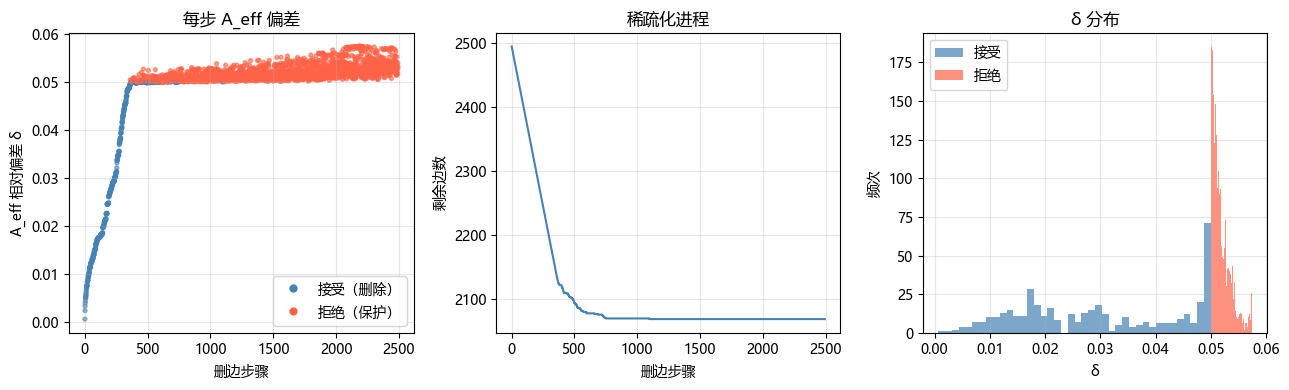

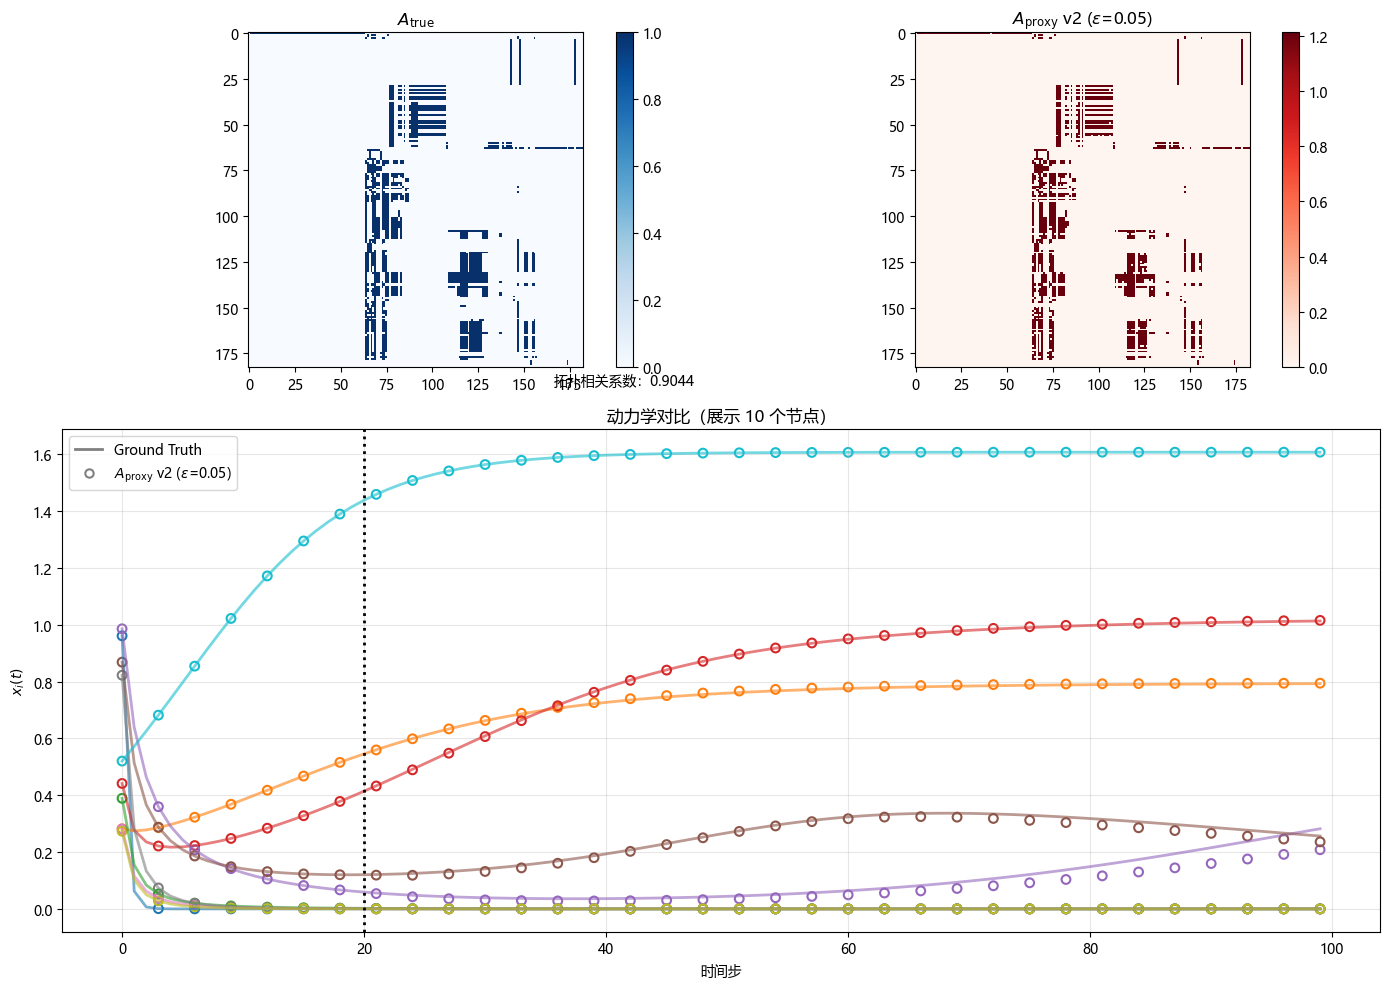

标签                                      全局 NRMSE
──────────────────────────────────────────────────
LASSO ($A_{\rm hat}$)                   0.164894
Algorithm v2 ($\varepsilon$=0.05)       0.064553


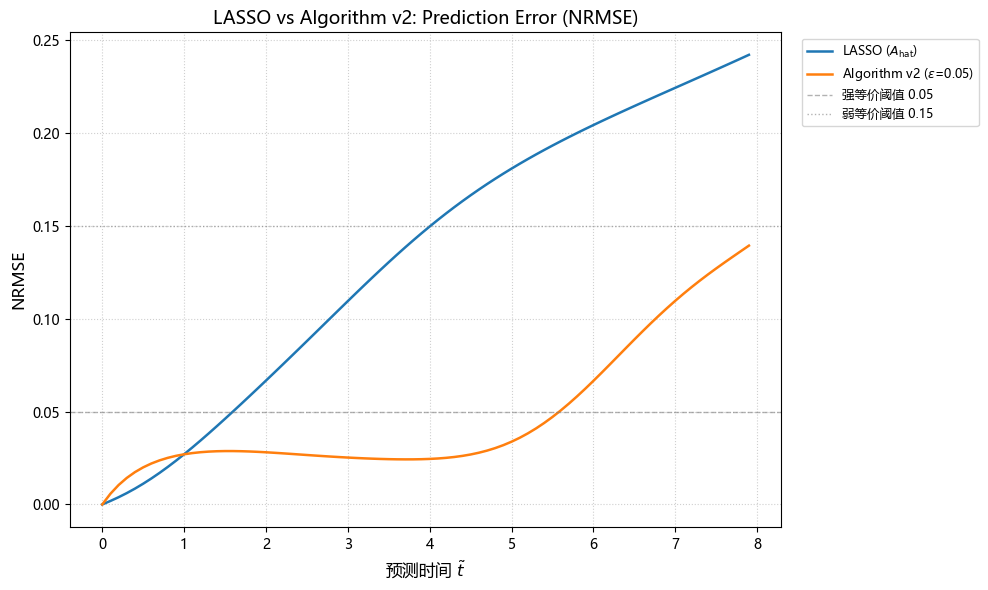

In [40]:
# ==============================================================
# Cell 4 — Algorithm v2: single run & diagnostics
# ==============================================================
A_proxy_v2, history_v2 = sparsify_network_v2(
    A_true, U_dyn, epsilon=0.05, verbose=True
)

# Diagnostic plot: delta scatter / edge count / delta histogram
plot_sparsification_path_v2(history_v2, save_path=None)

# Predict future trajectory with A_proxy_v2
steps_pred    = T_total - T_train
X_v2_future   = model.simulate(A_proxy_v2, T_steps=steps_pred, init_state=x0_pred)
X_v2_full     = np.vstack([X_train, X_v2_future])

# Trajectory comparison: A_true vs A_proxy_v2
plot_trajectory_comparison(
    A_true, A_proxy_v2, X_obs, X_v2_full,
    T_train_steps=T_train,
    num_nodes=10,
    name_proxy=r"$A_{\rm proxy}$ v2 ($\varepsilon$=0.05)",
    save_path=None
)

# LASSO vs Algorithm v2: NRMSE curves
X_hat_future = model.simulate(A_hat, T_steps=steps_pred, init_state=x0_pred)
X_hat_full   = np.vstack([X_train, X_hat_future])

plot_nrmse_comparison(
    X_obs,
    {
        "LASSO ($A_{\\rm hat}$)":          X_hat_full,
        r"Algorithm v2 ($\varepsilon$=0.05)": X_v2_full,
    },
    t_split=T_train,
    title="LASSO vs Algorithm v2: Prediction Error (NRMSE)",
    save_path=None
)

等价族构造完成：7 个稀疏度 × 5 个样本 = 35 个网络

     稀疏度     seed   δ(A_eff)    NRMSE      等价性
──────────────────────────────────────────────────
   0.300      342     0.8931   0.4254      不等价
   0.300      442     0.8927   0.4146      不等价
   0.300      542     0.8932   0.4282      不等价
   0.300      642     0.8925   0.3985      不等价
   0.300      742     0.8911   0.4005      不等价
   0.200      242     0.8799   0.4305      不等价
   0.200      342     0.8816   0.4265      不等价
   0.200      442     0.8820   0.4129      不等价
   0.200      542     0.8822   0.4136      不等价
   0.200      642     0.8804   0.3910      不等价
   0.150      192     0.8745   0.3963      不等价
   0.150      292     0.8732   0.4163      不等价
   0.150      392     0.8711   0.4055      不等价
   0.150      492     0.8724   0.3966      不等价
   0.150      592     0.8772   0.3945      不等价
   0.100      142     0.8652   0.4948      不等价
   0.100      242     0.8640   0.4807      不等价
   0.100      342     0.8672   0.4425      不等价
   0.100      442     0

C:\Users\liu.xuanc\AppData\Local\Temp\ipykernel_8036\942034452.py:121: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp   = ax.boxplot(data, labels=lbls, patch_artist=True)


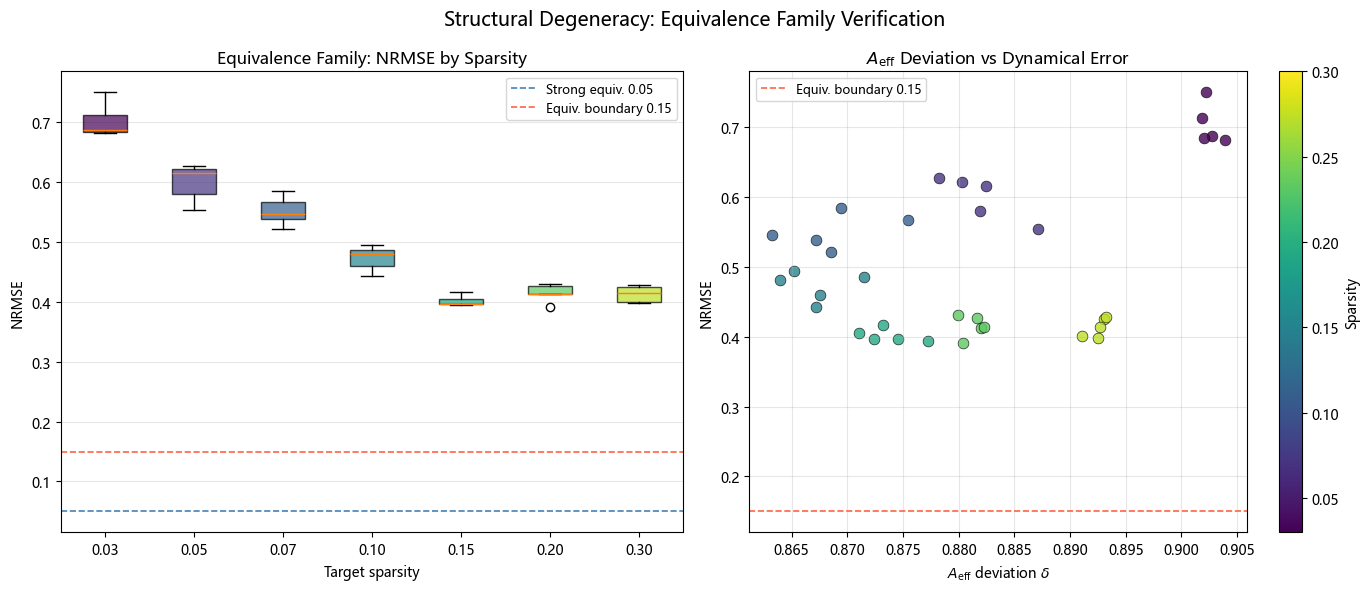

In [41]:
# ==============================================================
# Cell 5 — Equivalence family construction & verification
# Core experiment: can we construct structurally diverse networks
# that all share the same A_eff and drive the same dynamics?
# ==============================================================
A_eff_ref = compute_effective_matrix(A_true, U_dyn)
rho_ref   = float(np.max(np.abs(np.linalg.eigvals(A_true))))

# Sparsity levels to explore
# (fraction of edges relative to A_true; covers dense → sparse)
sparsity_levels = [0.30, 0.20, 0.15, 0.10, 0.07, 0.05, 0.03]

family = build_equivalence_family(
    A_eff_ref, U_dyn,
    sparsity_levels=sparsity_levels,
    n_samples_per_level=5,
    rho_ref=rho_ref,
    seed=SEED
)

# Run dynamics on every member and compute NRMSE
results_family = verify_equivalence_family(
    family, model, X_obs, T_train_steps=T_train,
    T_sim=500, seed=SEED
)

# Visualise: boxplot by sparsity + delta vs NRMSE scatter
plot_equivalence_family(
    results_family,
    nrmse_threshold=0.15,
    save_path=None
)

Epsilon percolation scan: 25 points
     eps  sparsity    delta    NRMSE    align       PR    rho_r
-----------------------------------------------------------------
  0.0100    0.9771   0.0455   0.0059   0.9969    13.36   1.0000
  0.0164    0.9415   0.1355   0.0159   0.9804    13.40   1.0000
  0.0229    0.9058   0.1392   0.0164   0.9669    13.43   1.0000
  0.0293    0.8813   0.1714   0.0198   0.9563    13.49   1.0000
  0.0357    0.8669   0.1474   0.0585   0.9469    13.49   1.0000
  0.0421    0.8549   0.2090   0.0564   0.9438    13.55   1.0000
  0.0486    0.8348   0.1864   0.0636   0.9265    13.57   1.0000
  0.0550    0.8123   0.2048   0.1103   0.9076    13.63   1.0000
  0.0614    0.7979   0.2054   0.1112   0.8914    13.70   1.0000
  0.0679    0.7871   0.2128   0.1112   0.8869    13.78   1.0000
  0.0743    0.7791   0.2681   0.1208   0.8824    13.83   1.0000
  0.0807    0.7715   0.2747   0.1208   0.8769    13.90   1.0000
  0.0871    0.7598   0.2706   0.1209   0.8679    13.98   1.0000
  

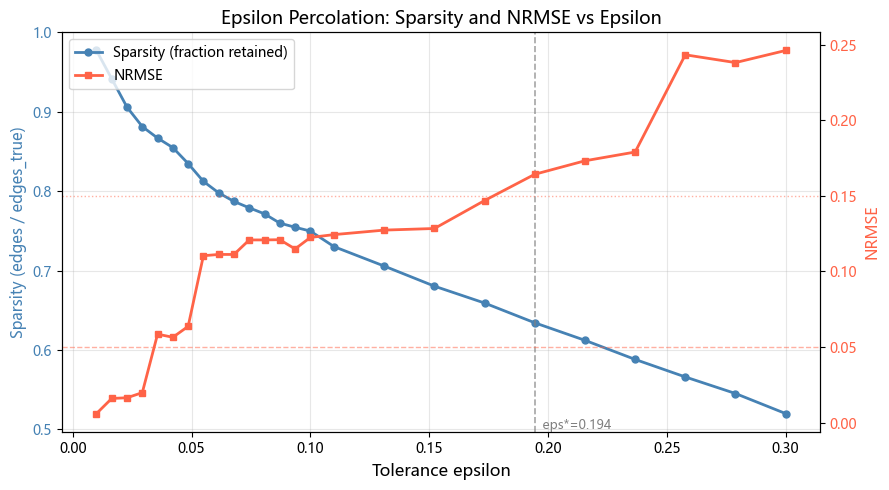

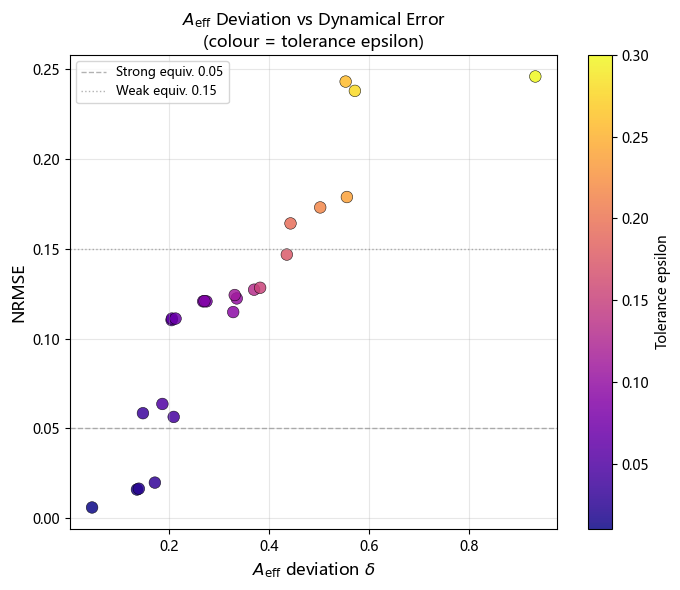

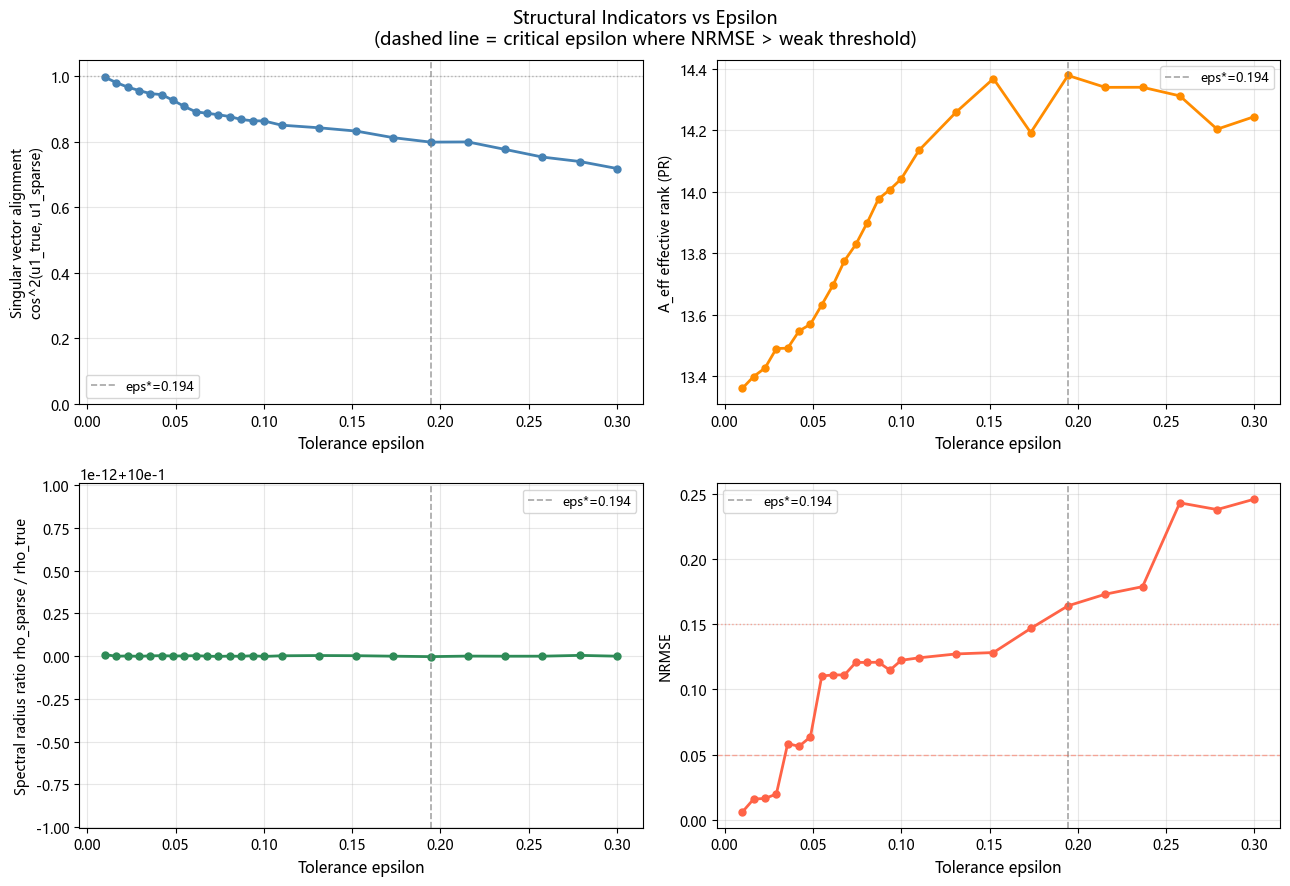

In [49]:
# ==============================================================
# Cell 6 — Epsilon percolation scan
# Sweep epsilon from tight to loose; record sparsity, delta, NRMSE.
# Identifies the critical epsilon epsilon* where NRMSE jumps.
# ==============================================================
epsilon_range = np.concatenate([
    np.linspace(0.01, 0.10, 15),   # fine resolution in tight region
    np.linspace(0.11, 0.30, 10),   # coarser resolution in loose region
])

perc_records = scan_epsilon_percolation(
    A_true, U_dyn, model, X_obs, T_train_steps=T_train,
    epsilon_range=np.sort(epsilon_range),
    T_sim=500, seed=SEED, verbose=True
)

# Figure 1: dual-axis epsilon vs sparsity & NRMSE
# Figure 2: delta vs NRMSE scatter coloured by epsilon
plot_epsilon_percolation(
    perc_records,
    nrmse_strong=0.05,
    nrmse_weak=0.15,
    save_path_main=None,
    save_path_scatter=None,
    save_path_indicators=None    # 新增，Figure 3 的保存路径
)


Demo network — sparsity: 30%, A_eff delta: 0.8925, NRMSE: 0.3985
A_demo edges : 9991
A_true edges : 2494


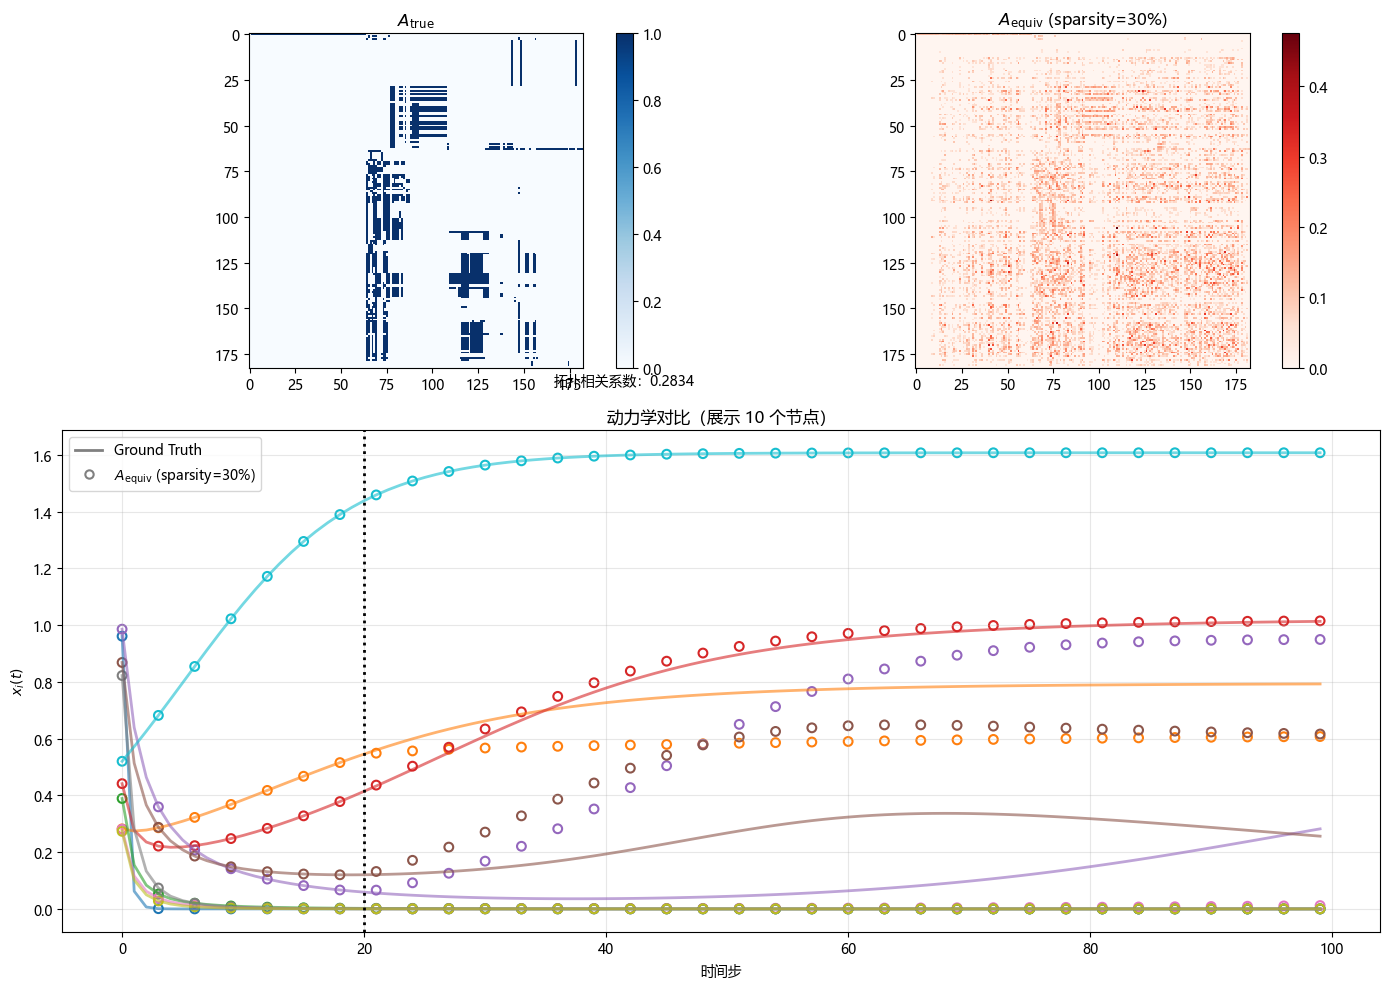

标签                                      全局 NRMSE
──────────────────────────────────────────────────
LASSO ($A_{\rm hat}$)                   0.164894
Equiv. network (sparsity=30%)           0.398479


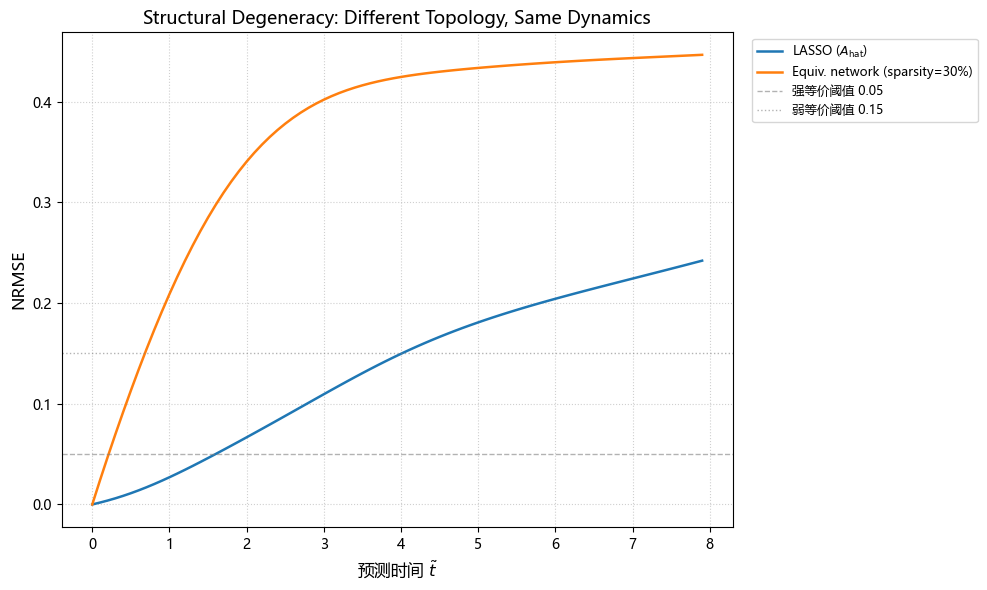

In [43]:
# ==============================================================
# Cell 7 — Single equivalence network: visual demonstration
# Pick one sparsity level and show that two structurally
# different networks both faithfully reproduce the dynamics.
# ==============================================================
# Choose the entry closest to 10 % sparsity from the family
target_sp = 0.30
demo_item  = min(
    [r for r in results_family if r['sparsity'] == target_sp],
    key=lambda r: r['nrmse']
)

A_demo = demo_item['A_equiv']
nrmse_demo = demo_item['nrmse']
print(f"\nDemo network — sparsity: {target_sp:.0%}, "
      f"A_eff delta: {demo_item['delta']:.4f}, NRMSE: {nrmse_demo:.4f}")
print(f"A_demo edges : {np.sum(np.abs(A_demo) > 1e-5)}")
print(f"A_true edges : {np.sum(np.abs(A_true) > 1e-5)}")

X_demo_future = model.simulate(A_demo, T_steps=steps_pred, init_state=x0_pred)
X_demo_full   = np.vstack([X_train, X_demo_future])

plot_trajectory_comparison(
    A_true, A_demo, X_obs, X_demo_full,
    T_train_steps=T_train,
    num_nodes=10,
    name_proxy=rf"$A_{{\rm equiv}}$ (sparsity={target_sp:.0%})",
    save_path=None
)

# NRMSE curve alongside LASSO baseline
plot_nrmse_comparison(
    X_obs,
    {
        "LASSO ($A_{\\rm hat}$)":                         X_hat_full,
        rf"Equiv. network (sparsity={target_sp:.0%})":   X_demo_full,
    },
    t_split=T_train,
    title="Structural Degeneracy: Different Topology, Same Dynamics",
    save_path=None
)